In [1]:
import pandas as pd

file_path = 'metadata.csv' 

# low_memory=False --> złożony plik
df = pd.read_csv(file_path, low_memory=False)


### podstawowa analiza
print("Kształt danych (wiersze, kolumny):")
print(df.shape)
print("-" * 30)

print("Pierwsze 5 wierszy:")
print(df.head())
print("-" * 30)

print("Info o typach danych:")
df.info()
print("-" * 30)


print("Kolumny:")
print(df.columns)
print("-" * 30)

print("Liczba brakujących wartości w kolumnach:")
print(df.isnull().sum())

Kształt danych (wiersze, kolumny):
(1056660, 19)
------------------------------
Pierwsze 5 wierszy:
   cord_uid                                       sha source_x  \
0  ug7v899j  d1aafb70c066a2068b02786f8929fd9c900897fb      PMC   
1  02tnwd4m  6b0567729c2143a66d737eb0a2f63f2dce2e5a7d      PMC   
2  ejv2xln0  06ced00a5fc04215949aa72528f2eeaae1d58927      PMC   
3  2b73a28n  348055649b6b8cf2b9a376498df9bf41f7123605      PMC   
4  9785vg6d  5f48792a5fa08bed9f56016f4981ae2ca6031b32      PMC   

                                               title                    doi  \
0  Clinical features of culture-proven Mycoplasma...  10.1186/1471-2334-1-6   
1  Nitric oxide: a pro-inflammatory mediator in l...           10.1186/rr14   
2    Surfactant protein-D and pulmonary host defense           10.1186/rr19   
3               Role of endothelin-1 in lung disease           10.1186/rr44   
4  Gene expression in epithelial cells in respons...           10.1186/rr61   

      pmcid pubmed_id licens

In [2]:
print(f"Rozmiar danych przed czyszczeniem: {df.shape}")

### tylko potrzebne kolumny: title i abstract
### .copy()  -->  nowa niezależna ramka danych
df_clean = df[['title', 'abstract']].copy()

### usunięcie wierszy, w których brak jednoczesnie tytułu i abstraktu
### wiersz zostanie usunięty tylko jeśli wszystkie wartości w podanych kolumnach subset są puste (NaN)
df_clean.dropna(subset=['title', 'abstract'], how='all', inplace=True)

print(f"Rozmiar po usunięciu wierszy bez tytułu i abstraktu: {df_clean.shape}")

### usunięcie duplikatów na podstawie kolumny title
df_clean.drop_duplicates(subset=['title'], inplace=True)

print(f"Rozmiar po usunięciu duplikatów: {df_clean.shape}")


print("\nLiczba brakujących wartości po czyszczeniu:")
print(df_clean.isnull().sum())


print("\nPróbka danych po czyszczeniu:")
print(df_clean.head())

Rozmiar danych przed czyszczeniem: (1056660, 19)
Rozmiar po usunięciu wierszy bez tytułu i abstraktu: (1056268, 2)
Rozmiar po usunięciu duplikatów: (850367, 2)

Liczba brakujących wartości po czyszczeniu:
title            1
abstract    176878
dtype: int64

Próbka danych po czyszczeniu:
                                               title  \
0  Clinical features of culture-proven Mycoplasma...   
1  Nitric oxide: a pro-inflammatory mediator in l...   
2    Surfactant protein-D and pulmonary host defense   
3               Role of endothelin-1 in lung disease   
4  Gene expression in epithelial cells in respons...   

                                            abstract  
0  OBJECTIVE: This retrospective chart review des...  
1  Inflammatory diseases of the respiratory tract...  
2  Surfactant protein-D (SP-D) participates in th...  
3  Endothelin-1 (ET-1) is a 21 amino acid peptide...  
4  Respiratory syncytial virus (RSV) and pneumoni...  


In [3]:
import re

### zastąpienie wartości NaN pustym tekstem ''
df_clean.fillna('', inplace=True)

### nowa połączona kolumna 'text' ### spacja ' ' pomiędzy aby tytuł nie skleił się z abstraktem
df_clean['text'] = df_clean['title'] + ' ' + df_clean['abstract']

### funkcja do czyszczenia tekstu
def preprocess_text(text):
    text = text.lower()  ## zamiana na małe litery
    text = re.sub(r'[^\w\s]', '', text)  ## usunięcie interpunkcji
    text = re.sub(r'\d+', '', text)  ## usunięcie cyfr
    text = re.sub(r'\s+', ' ', text).strip() ## usunięcie nadmiarowych białych znaków
    return text


print("Czyszczenie tekstu...")
df_clean['text_clean'] = df_clean['text'].apply(preprocess_text)
print("Czyszczenie zakończone.")

### 5 wierszy z kolumną oryginalną i wyczyszczoną dla porównania
print("\nPorównanie tekstu oryginalnego i wyczyszczonego:")
print(df_clean[['text', 'text_clean']].head())

Czyszczenie tekstu...
Czyszczenie zakończone.

Porównanie tekstu oryginalnego i wyczyszczonego:
                                                text  \
0  Clinical features of culture-proven Mycoplasma...   
1  Nitric oxide: a pro-inflammatory mediator in l...   
2  Surfactant protein-D and pulmonary host defens...   
3  Role of endothelin-1 in lung disease Endotheli...   
4  Gene expression in epithelial cells in respons...   

                                          text_clean  
0  clinical features of cultureproven mycoplasma ...  
1  nitric oxide a proinflammatory mediator in lun...  
2  surfactant proteind and pulmonary host defense...  
3  role of endothelin in lung disease endothelin ...  
4  gene expression in epithelial cells in respons...  


In [4]:
import spacy
from tqdm import tqdm
import time

### preprocessing z Lematyzacją
nlp = spacy.load('en_core_web_lg', disable=['parser', 'ner']) ## wyłącza komponenty (parser, ner) aby przyspieszyć proces
print("Model załadowany.")

## funkcja do lematyzacji i usuwania stop words
def lemmatize_text(text):
    doc = nlp(text)
    
    # lista lemmatów bez stop words i znaków interpunkcyjnych
    lemmas = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    
    # łączy lemmaty z powrotem w jeden tekst
    return " ".join(lemmas)

## mniejsza próba
print("\nPrzetwarzanie próby 10000 dokumentów...")
df_sample = df_clean.sample(10000, random_state=42)

start_time = time.time()

df_sample_lemmatized = df_sample.copy()
df_sample_lemmatized['text_lemmatized'] = df_sample_lemmatized['text_clean'].apply(lemmatize_text)

end_time = time.time()
print(f"Przetwarzanie próbki zakończone w {(end_time - start_time):.2f} sekund.")


## wyniki
print("\nPorównanie tekstu wyczyszczonego i zlemmatyzowanego:")
print(df_sample_lemmatized[['text_clean', 'text_lemmatized']].head())

Model załadowany.

Przetwarzanie próby 10000 dokumentów...
Przetwarzanie próbki zakończone w 105.69 sekund.

Porównanie tekstu wyczyszczonego i zlemmatyzowanego:
                                               text_clean  \
666494  potent noncovalent inhibitors of the main prot...   
304385  social study resources and social wellbeing be...   
143551  younger adults caught in covid crosshairs as d...   
796106  individuals conceptions of covid pandemic thro...   
283352  profiles of antibody responses against severe ...   

                                          text_lemmatized  
666494  potent noncovalent inhibitor main protease sar...  
304385  social study resource social wellbeing intelli...  
143551  young adult catch covid crosshair demographic ...  
796106  individual conception covid pandemic metaphor ...  
283352  profile antibody response severe acute respira...  


In [10]:
### przetwarzanie (lematyzacja) dla pełnego zbioru (wersja z nlp.pipe)

print("\nRozpoczynam przetwarzanie pełnego zbioru...")
start_time = time.time()


lemmatized_texts = []
### batch_size=500 spaCy przetwarza dokumenty po 500
for doc in tqdm(nlp.pipe(df_clean['text_clean'], batch_size=500), total=len(df_clean)):
    lemmas = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    lemmatized_texts.append(" ".join(lemmas))


df_clean['text_lemmatized'] = lemmatized_texts


end_time = time.time()
total_time_minutes = (end_time - start_time) / 60
print(f"\nPrzetwarzanie pełnego zbioru zakończone w {total_time_minutes:.2f} minut.")


## wyniki
print("\nPorównanie tekstu wyczyszczonego i zlemmatyzowanego:")
print(df_clean[['text_clean', 'text_lemmatized']].head())


Rozpoczynam przetwarzanie pełnego zbioru...


100%|██████████| 850367/850367 [2:18:51<00:00, 102.07it/s]  



Przetwarzanie pełnego zbioru zakończone w 138.86 minut.

Porównanie tekstu wyczyszczonego i zlemmatyzowanego:
                                          text_clean  \
0  clinical features of cultureproven mycoplasma ...   
1  nitric oxide a proinflammatory mediator in lun...   
2  surfactant proteind and pulmonary host defense...   
3  role of endothelin in lung disease endothelin ...   
4  gene expression in epithelial cells in respons...   

                                     text_lemmatized  
0  clinical feature cultureproven mycoplasma pneu...  
1  nitric oxide proinflammatory mediator lung dis...  
2  surfactant proteind pulmonary host defense sur...  
3  role endothelin lung disease endothelin et ami...  
4  gene expression epithelial cell response pneum...  


In [12]:
import joblib

joblib.dump(df_clean, 'df_clean_lemmatized.joblib')
print("DataFrame zapisany w pliku df_clean_lemmatized.joblib")

DataFrame zapisany w pliku df_clean_lemmatized.joblib


In [1]:
import pandas as pd
import spacy
from tqdm import tqdm
import time
import re
import joblib

### wczytywanie obiektu
df_clean = joblib.load('df_clean_lemmatized.joblib')

print("Obiekt wczytany.")

Obiekt wczytany.


In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np

#### wektoryzacja ze SPECTER
### model 'allenai-specter' specjalnie zaprojektowany do reprezentacji artykułów naukowych
model = SentenceTransformer('allenai-specter', device='cuda')
print("Model załadowany.")

## próbka
n_samples = 20000
df_sample = df_clean.sample(n=n_samples, random_state=42)
texts_to_encode = df_sample['text_lemmatized'].tolist()

### kodowanie tekstów na wektory (embeddings)
start_time = time.time()

embeddings_sample = model.encode(texts_to_encode, 
                                 show_progress_bar=True, ### pokaże pasek postępu
                                 batch_size=512)

end_time = time.time()
print(f"Kodowanie próbki zakończone w {(end_time - start_time):.2f} sekund.")

### wyniki
print("\nKształt macierzy:")
print(embeddings_sample.shape)

### wynik dla próbki
np.save('embeddings_sample.npy', embeddings_sample)
print("Próbka zapisana w pliku 'embeddings_sample.npy'")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Greg Z\.cache\huggingface\hub\models--sentence-transformers--allenai-specter. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model załadowany.


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Kodowanie próbki zakończone w 48.70 sekund.

Kształt macierzy:
(20000, 768)
Próbka zapisana w pliku 'embeddings_sample.npy'


In [5]:
### przetwarzanie pełnego zbioru (SPECTER)

texts_to_encode_full = df_clean['text_lemmatized'].tolist()

start_time = time.time()

embeddings_full = model.encode(texts_to_encode_full, 
                               show_progress_bar=True,
                               batch_size=512)

end_time = time.time()
total_time_minutes = (end_time - start_time) / 60
print(f"\nKodowanie pełnego zbioru zakończone w {total_time_minutes:.2f} minut.")

### wynik
print("\nKształt finalnej macierzy:")
print(embeddings_full.shape)

### zapis
np.save('embeddings_full.npy', embeddings_full)
print("Pełny zbiór zapisany do pliku 'embeddings_full.npy'")

Batches:   0%|          | 0/1661 [00:00<?, ?it/s]


Kodowanie pełnego zbioru zakończone w 33.79 minut.

Kształt finalnej macierzy:
(850367, 768)
Pełny zbiór zapisany do pliku 'embeddings_full.npy'


In [1]:
import pandas as pd
import spacy
from tqdm import tqdm
import time
import re
import joblib
from sentence_transformers import SentenceTransformer
import numpy as np

### wczytywanie obiektów
df_clean = joblib.load('df_clean_lemmatized.joblib')

embeddings_full = np.load('embeddings_full.npy')

print("Obiekty wczytane.")


Obiekty wczytane.


In [3]:
import umap.umap_ as umap

### redukcja wymiarowości z UMAP (z 768 wymiarów do 10)

print(f"Redukcja wymiarowości z 768 do 10 dla {embeddings_full.shape[0]} wektorów...")
start_time = time.time()

### konfiguracja UMAP
## n_neighbors=15 - kontroluje balans między lokalną a globalną strukturą
## n_components=10 - wymiar docelowy, na który redukujemy dane
## min_dist=0.1 - minimalny dystans między punktami (jak gęsto mają być upakowane)
## metric='cosine' - kluczowe dla danych tekstowych, odległość jest mierzona kątem, a nie odległością euklidesową

reducer = umap.UMAP(
    n_neighbors=15,
    n_components=10,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
    verbose=True
)

### uruchomienie
umap_embeddings = reducer.fit_transform(embeddings_full)

end_time = time.time()
total_time_minutes = (end_time - start_time) / 60
print(f"\nRedukcja wymiarowości zakończona w {total_time_minutes:.2f} minut.")

### wynik i zapis
print("\nKształt macierzy po redukcji UMAP:")
print(umap_embeddings.shape)

np.save('umap_embeddings_10d.npy', umap_embeddings)
print("Osadzenia UMAP zostały zapisane w pliku umap_embeddings_10d.npy")

Redukcja wymiarowości z 768 do 10 dla 850367 wektorów...


O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', n_components=10, n_jobs=1, random_state=42, verbose=True)
Wed Aug 27 21:10:48 2025 Construct fuzzy simplicial set
Wed Aug 27 21:10:48 2025 Finding Nearest Neighbors
Wed Aug 27 21:10:48 2025 Building RP forest with 51 trees
Wed Aug 27 21:11:56 2025 NN descent for 20 iterations
	 1  /  20
	 2  /  20
	 3  /  20
	 4  /  20
	 5  /  20
	Stopping threshold met -- exiting after 5 iterations
Wed Aug 27 21:13:02 2025 Finished Nearest Neighbor Search
Wed Aug 27 21:13:05 2025 Construct embedding


O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed Aug 27 21:22:48 2025 Finished embedding

Redukcja wymiarowości zakończona w 12.07 minut.

Kształt macierzy po redukcji UMAP:
(850367, 10)
Osadzenia UMAP zostały zapisane w pliku umap_embeddings_10d.npy


In [1]:
import pandas as pd
import spacy
from tqdm import tqdm
import time
import re
import joblib
from sentence_transformers import SentenceTransformer
import numpy as np

### wczytywanie obiektów
df_clean = joblib.load('df_clean_lemmatized.joblib')

umap_embeddings = np.load('umap_embeddings_10d.npy')

print("Obiekty wczytane.")


Obiekty wczytane.


HDBSCAN

In [4]:
## HDBSCAN

import hdbscan

### konfiguracja HDBSCAN
## min_cluster_size - minimalna liczba dokumentów żeby uznawało za osobny klaster
## min_samples - im wyższa tym więcej punktów uzna za szum
## metric='euclidean' - standardowa metryka dla danych po redukcji UMAP

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=150,
    min_samples=15,
    metric='euclidean',
    cluster_selection_method='eom'
)


start_time = time.time()

### uruchomienie
clusterer.fit(umap_embeddings)


end_time = time.time()
total_time_minutes = (end_time - start_time) / 60
print(f"\nKlastrowanie HDBSCAN zakończone w {total_time_minutes:.2f} minut.")


### dodanie wyników etykiet klastrów do dataframe
df_clean['hdbscan_cluster'] = clusterer.labels_


### wynik znalezionych klastrów (-1 to szum)
n_clusters = len(pd.unique(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
n_noise = list(clusterer.labels_).count(-1) ### szum

print(f"\nZnaleziono klastrów: {n_clusters}")
print(f"Liczba punktów oznaczonych jako szum: {n_noise} ({n_noise / len(df_clean) * 100:.2f}%)")


print("\nLiczebność 20 największych klastrów (klaster -1 to szum):")

print(df_clean['hdbscan_cluster'].value_counts().head(20))

O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Klastrowanie HDBSCAN zakończone w 0.94 minut.

Znaleziono klastrów: 492
Liczba punktów oznaczonych jako szum: 504165 (59.29%)

Liczebność 20 największych klastrów (klaster -1 to szum):
hdbscan_cluster
-1      504165
 436      8003
 1        6293
 79       5997
 389      4957
 359      4344
 272      4316
 261      4219
 232      4183
 402      4102
 447      3905
 27       3860
 277      3366
 437      3333
 286      3232
 134      3224
 255      3182
 443      3130
 380      3081
 413      3054
Name: count, dtype: int64


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

### analiza tematyczna największych klastrów HDBSCAN
## pomijając szum

top_clusters_ids = df_clean['hdbscan_cluster'].value_counts().drop(-1).head(5).index.tolist()

print("ANALIZA SŁÓW KLUCZOWYCH DLA NAJWIĘKSZYCH KLASTRÓW")
print("="*30)

for cluster_id in top_clusters_ids:
    cluster_texts = df_clean[df_clean['hdbscan_cluster'] == cluster_id]['text_lemmatized']
    
    ## TF-IDF - kluczowe słowa dla tego klastra
    vectorizer = TfidfVectorizer(max_features=10) ### 10 najważniejszych słów
    vectorizer.fit(cluster_texts)
    
    top_words = vectorizer.get_feature_names_out()
    
    print(f"\nKlaster {cluster_id} (Liczba dokumentów: {len(cluster_texts)})")
    print(f"Słowa kluczowe: {', '.join(top_words)}")

ANALIZA SŁÓW KLUCZOWYCH DLA NAJWIĘKSZYCH KLASTRÓW

Klaster 436 (Liczba dokumentów: 8003)
Słowa kluczowe: case, covid, datum, disease, epidemic, infection, model, number, pandemic, spread

Klaster 1 (Liczba dokumentów: 6293)
Słowa kluczowe: covid, disease, eye, method, ocular, pandemic, patient, result, retinal, study

Klaster 79 (Liczba dokumentów: 5997)
Słowa kluczowe: care, covid, infection, maternal, outcome, pregnancy, pregnant, sarscov, study, woman

Klaster 389 (Liczba dokumentów: 4957)
Słowa kluczowe: analysis, covid, information, medium, model, news, pandemic, sentiment, social, tweet

Klaster 359 (Liczba dokumentów: 4344)
Słowa kluczowe: abstract, covid, editor, editorial, issue, meeting, new, research, time, year


In [8]:
###### dostrajanie HDBSCAN z min_cluster_size=75

### konfiguracja modelu z nowym, niższym progiem
clusterer_v2 = hdbscan.HDBSCAN(
    min_cluster_size=75,
    min_samples=15,
    metric='euclidean',
    cluster_selection_method='eom'
)


start_time = time.time()

### uruchomienie klastrowania
clusterer_v2.fit(umap_embeddings)

end_time = time.time()
total_time_minutes = (end_time - start_time) / 60
print(f"\nKlastrowanie zakończone w {total_time_minutes:.2f} minut.")


### nadpisanie wcześniejszej kolumny z etykietami klastrów
df_clean['hdbscan_cluster'] = clusterer_v2.labels_

### wynik znalezionych klastrów (-1 to szum)
n_clusters = len(pd.unique(clusterer_v2.labels_)) - (1 if -1 in clusterer_v2.labels_ else 0)
n_noise = list(clusterer_v2.labels_).count(-1)

print(f"\nZnaleziono klastrów: {n_clusters}")
print(f"Liczba punktów oznaczonych jako szum: {n_noise} ({n_noise / len(df_clean) * 100:.2f}%)")


print("\nLiczebność 20 największych klastrów (klaster -1 to szum):")

print(df_clean['hdbscan_cluster'].value_counts().head(20))

O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Klastrowanie zakończone w 0.93 minut.

Znaleziono klastrów: 884
Liczba punktów oznaczonych jako szum: 508360 (59.78%)

Liczebność 20 największych klastrów (klaster -1 to szum):
hdbscan_cluster
-1      508360
 809      8003
 2        6293
 153      5997
 503      4316
 434      4072
 476      4014
 54       3860
 810      3333
 250      3224
 754      3194
 817      3130
 707      3081
 346      2921
 179      2863
 515      2792
 831      2685
 194      2643
 603      2542
 444      2355
Name: count, dtype: int64


In [10]:
### przywracamy pierwszą i najlepszą konfigurację dla HDBSCAN + zapis wyników

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=150,
    min_samples=15,
    metric='euclidean',
    cluster_selection_method='eom'
)


start_time = time.time()

### uruchomienie
clusterer.fit(umap_embeddings)


end_time = time.time()
total_time_minutes = (end_time - start_time) / 60
print(f"\nKlastrowanie HDBSCAN zakończone w {total_time_minutes:.2f} minut.")


### dodanie wyników etykiet klastrów do dataframe
df_clean['hdbscan_cluster'] = clusterer.labels_


### wynik znalezionych klastrów (-1 to szum)
n_clusters = len(pd.unique(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
n_noise = list(clusterer.labels_).count(-1) ### szum

print(f"\nZnaleziono klastrów: {n_clusters}")
print(f"Liczba punktów oznaczonych jako szum: {n_noise} ({n_noise / len(df_clean) * 100:.2f}%)")


print("\nLiczebność 20 największych klastrów (klaster -1 to szum):")

print(df_clean['hdbscan_cluster'].value_counts().head(20))


### zapis wyników (wersja DataFrame z przypisanymi klastrami HDBSCAN + obiekt wytrenowanego modelu)
joblib.dump(df_clean, 'df_final_hdbscan_clusters.joblib')
print("DataFrame zapisany w df_final_hdbscan_clusters.joblib")


joblib.dump(clusterer, 'hdbscan_model_final.joblib')
print("Model HDBSCAN zapisany w hdbscan_model_final.joblib")

O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Klastrowanie HDBSCAN zakończone w 0.93 minut.

Znaleziono klastrów: 492
Liczba punktów oznaczonych jako szum: 504165 (59.29%)

Liczebność 20 największych klastrów (klaster -1 to szum):
hdbscan_cluster
-1      504165
 436      8003
 1        6293
 79       5997
 389      4957
 359      4344
 272      4316
 261      4219
 232      4183
 402      4102
 447      3905
 27       3860
 277      3366
 437      3333
 286      3232
 134      3224
 255      3182
 443      3130
 380      3081
 413      3054
Name: count, dtype: int64
DataFrame zapisany w df_final_hdbscan_clusters.joblib
Model HDBSCAN zapisany w hdbscan_model_final.joblib


In [1]:
import pandas as pd
import spacy
from tqdm import tqdm
import time
import re
import joblib
from sentence_transformers import SentenceTransformer
import numpy as np
import hdbscan

### wczytywanie obiektów
df_clean_hdbscan = joblib.load('df_final_hdbscan_clusters.joblib')

umap_embeddings = np.load('umap_embeddings_10d.npy')

clusterer = joblib.load('hdbscan_model_final.joblib')

print("Obiekty wczytane.")


Obiekty wczytane.


O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Redukcja do 2D zakończona.


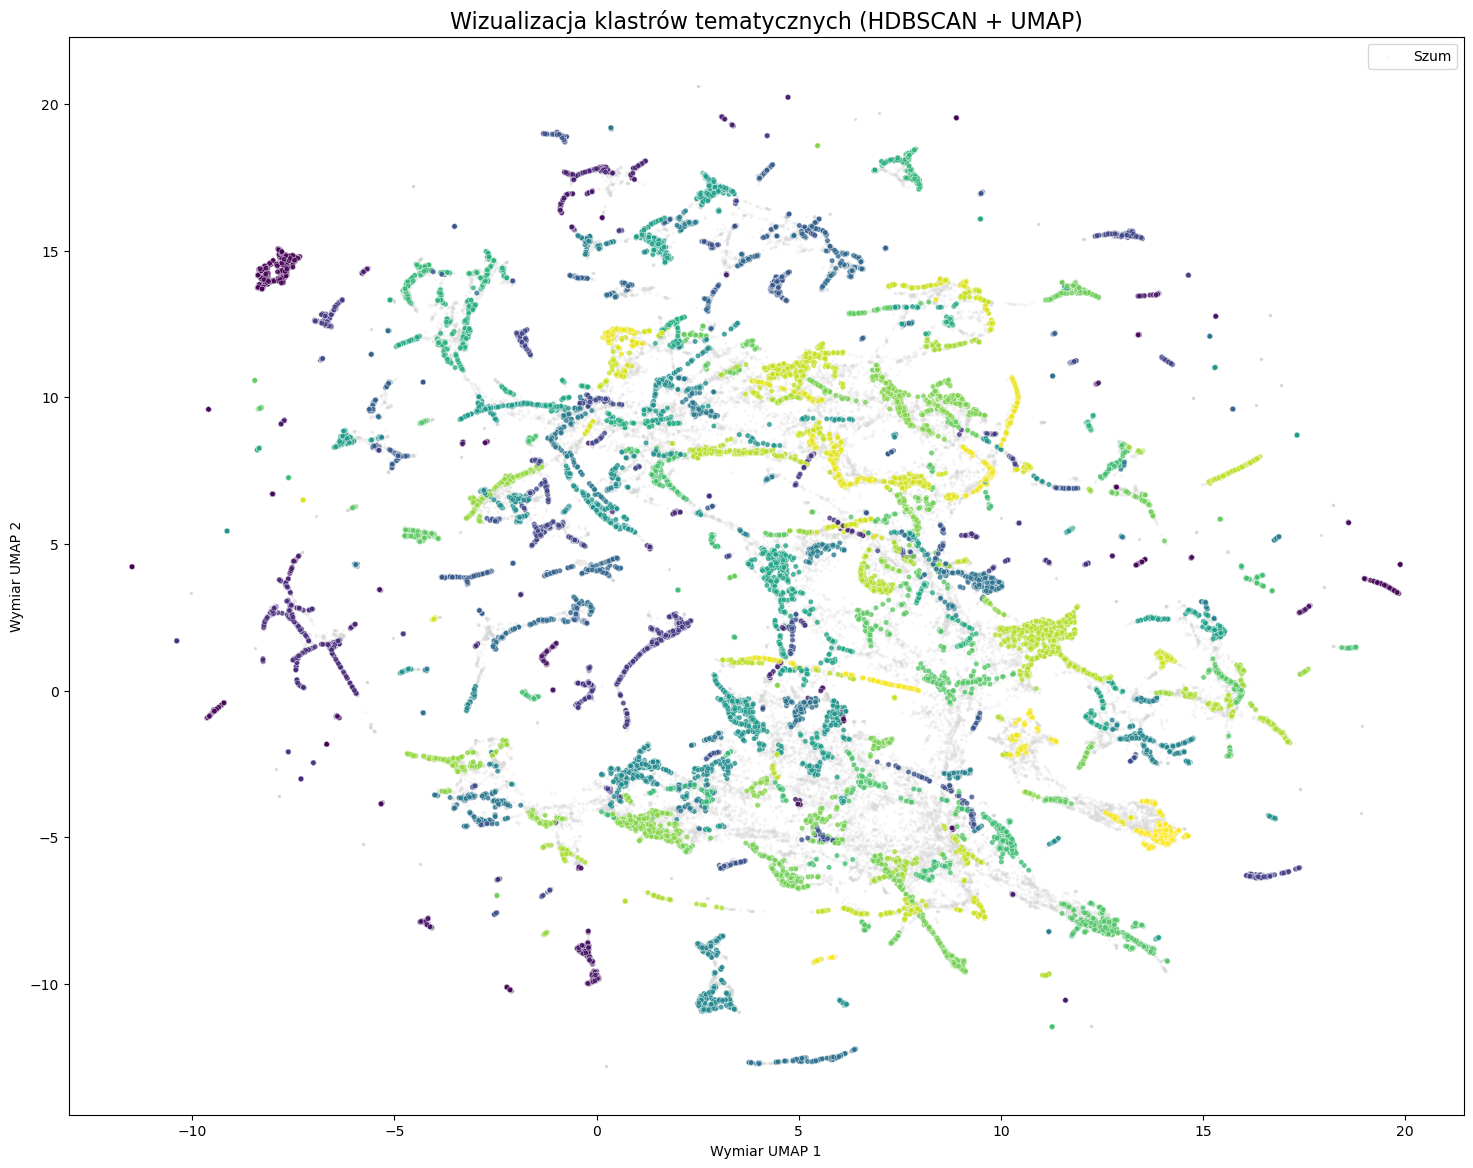

In [3]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

### wizualizacja 2D

## próbka do wizualizacji
n_samples_viz = 75000
random_indices = np.random.choice(umap_embeddings.shape[0], size=n_samples_viz, replace=False)

## dane wejściowe (10 wymiarów) i etykiety klastrów dla naszej próbki
umap_embeddings_sample = umap_embeddings[random_indices]
cluster_labels_sample = df_clean_hdbscan['hdbscan_cluster'].iloc[random_indices]

## redukcja wymiarów z 10D do 2D z UMAP
reducer_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
embeddings_2d = reducer_2d.fit_transform(umap_embeddings_sample)
print("Redukcja do 2D zakończona.")

## DataFrame do rysowania
df_viz = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'cluster': cluster_labels_sample
})


## wykres
plt.figure(figsize=(18, 14))

## oddzielanie szumu od sklastrowanych
df_noise = df_viz[df_viz['cluster'] == -1]
df_clusters = df_viz[df_viz['cluster'] != -1]

## szum jako szare (przezroczyste tło)
sns.scatterplot(
    x=df_noise['x'], y=df_noise['y'],
    color='#D3D3D3',
    s=5,             #### mały rozmiar punktu
    alpha=0.2,       #### wysoka przezroczystość
    label='Szum'
)

## na wierzchu kolorowe klastry
sns.scatterplot(
    x=df_clusters['x'], y=df_clusters['y'],
    hue=df_clusters['cluster'],
    palette='viridis',
    s=15,
    alpha=0.8,
    legend=None      #### wyłączona legenda bo setki klastrów
)

plt.title('Wizualizacja klastrów tematycznych (HDBSCAN + UMAP)', fontsize=16)
plt.xlabel('Wymiar UMAP 1')
plt.ylabel('Wymiar UMAP 2')
plt.show()

O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Redukcja do 2D zakończona.


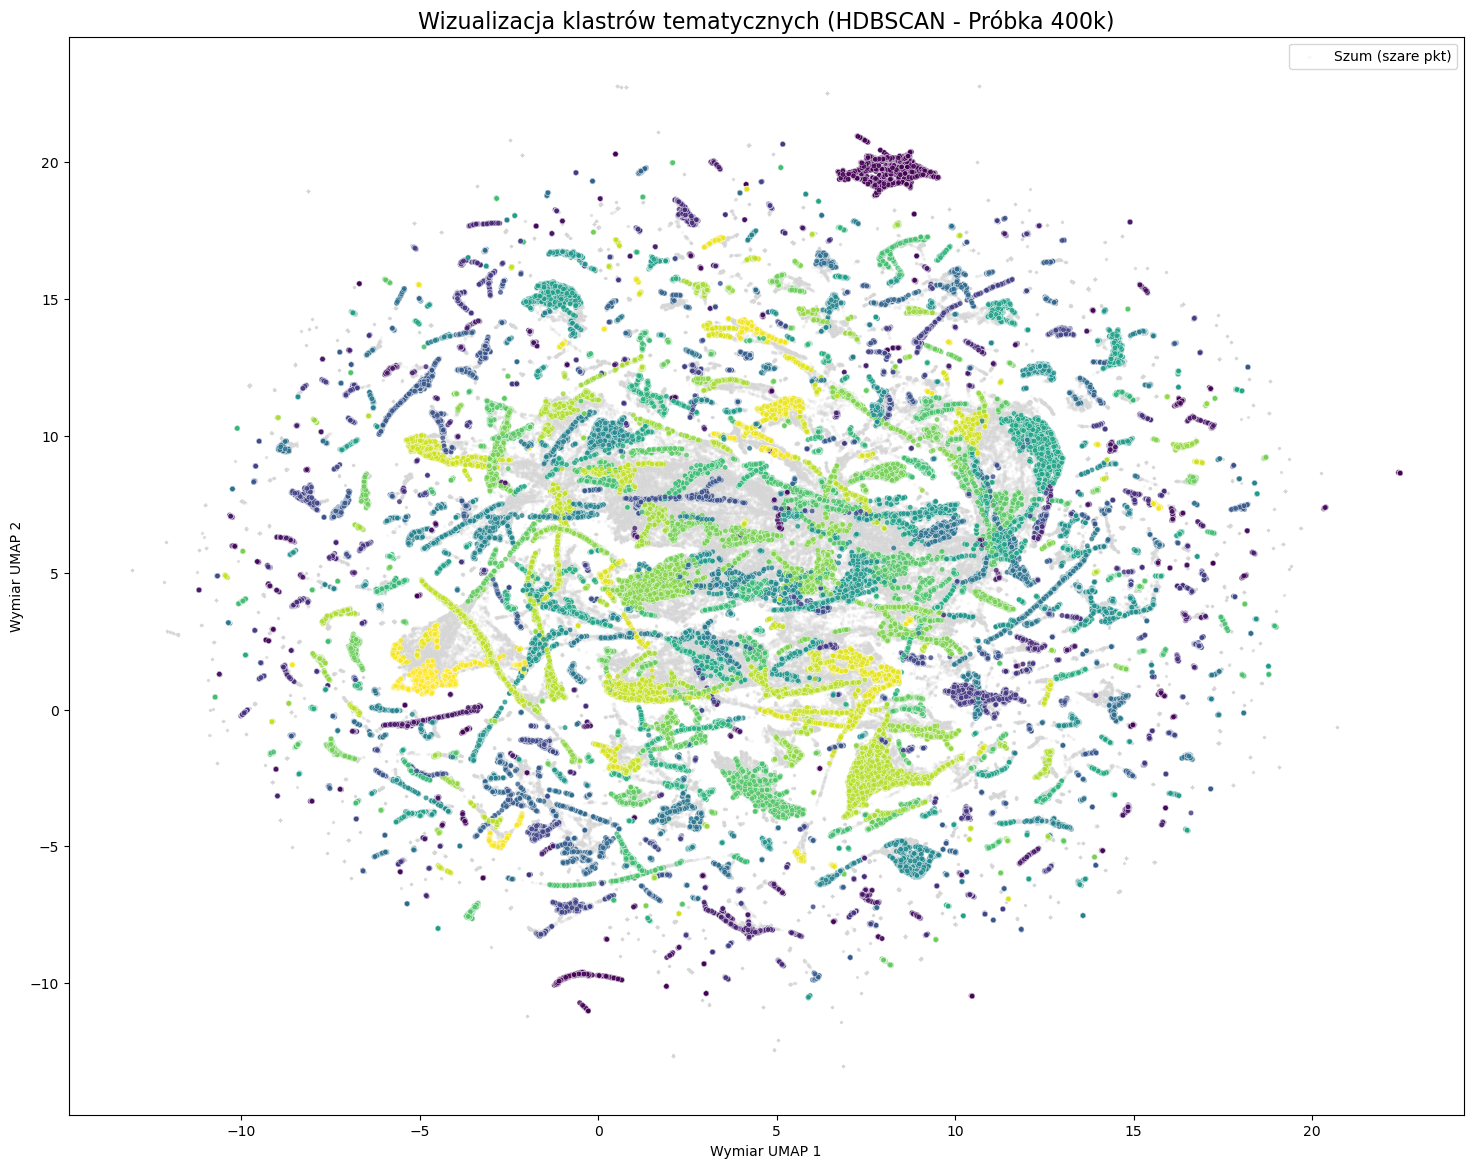

In [5]:
### wizualizacja 2D dla połowy punktów / próbek

## próbka do wizualizacji 400k
n_samples_viz = 400000
random_indices = np.random.choice(umap_embeddings.shape[0], size=n_samples_viz, replace=False)

## dane wejściowe (10 wymiarów) i etykiety klastrów dla naszej próbki
umap_embeddings_sample = umap_embeddings[random_indices]
cluster_labels_sample = df_clean_hdbscan['hdbscan_cluster'].iloc[random_indices]

## redukcja wymiarów z 10D do 2D z UMAP
reducer_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
embeddings_2d = reducer_2d.fit_transform(umap_embeddings_sample)
print("Redukcja do 2D zakończona.")

## DataFrame do rysowania
df_viz = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'cluster': cluster_labels_sample
})


## wykres
plt.figure(figsize=(18, 14))

## oddzielanie szumu od sklastrowanych
df_noise = df_viz[df_viz['cluster'] == -1]
df_clusters = df_viz[df_viz['cluster'] != -1]

## szum jako szare (przezroczyste tło)
sns.scatterplot(
    x=df_noise['x'], y=df_noise['y'],
    color='#D3D3D3',
    s=5,             #### mały rozmiar punktu
    alpha=0.2,       #### wysoka przezroczystość
    label='Szum (szare pkt)'
)

## na wierzchu kolorowe klastry
sns.scatterplot(
    x=df_clusters['x'], y=df_clusters['y'],
    hue=df_clusters['cluster'],
    palette='viridis',
    s=15,
    alpha=0.8,
    legend=None      #### wyłączona legenda bo setki klastrów
)

plt.title('Wizualizacja klastrów tematycznych (HDBSCAN - Próbka 400k)', fontsize=16)
plt.xlabel('Wymiar UMAP 1')
plt.ylabel('Wymiar UMAP 2')
plt.show()

In [1]:
import pandas as pd
import spacy
from tqdm import tqdm
import time
import re
import joblib
from sentence_transformers import SentenceTransformer
import numpy as np
import hdbscan

### wczytywanie obiektów
df_clean_hdbscan = joblib.load('df_final_hdbscan_clusters.joblib')

umap_embeddings = np.load('umap_embeddings_10d.npy')

clusterer = joblib.load('hdbscan_model_final.joblib')

print("Obiekty wczytane.")


Obiekty wczytane.


In [3]:
### Klastrowanie za pomocą KMeans 

from sklearn.cluster import KMeans

## konfiguracja modelu KMeans
n_clusters = 20
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init='auto'
)


start_time = time.time()

## uruchomienie klastrowania na danych z UMAP
kmeans.fit(umap_embeddings)

end_time = time.time()

print(f"Klastrowanie KMeans zakończone w {((end_time - start_time)/60):.2f} minut.")


## wyniki
### nowa kolumna z dodanym wynikiem klastrowania kmeans
df_clean_hdbscan['kmeans_cluster'] = kmeans.labels_

## liczebność poszczególnych klastrów
print("\nLiczebność klastrów znalezionych przez KMeans:")
print(df_clean_hdbscan['kmeans_cluster'].value_counts().sort_index())

Klastrowanie KMeans zakończone w 0.04 minut.

Liczebność klastrów znalezionych przez KMeans:
kmeans_cluster
0     83598
1     62660
2     30296
3     13106
4     30952
5     32972
6     59992
7     66014
8      6359
9     56827
10    71483
11    40433
12    42294
13    34108
14    32796
15    42679
16    28090
17    89282
18    11814
19    14612
Name: count, dtype: int64


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

## analiza tematyczna klastrów KMeans

### 5 największych klastrów
top_kmeans_ids = df_clean_hdbscan['kmeans_cluster'].value_counts().head(5).index.tolist()

print("ANALIZA SŁÓW KLUCZOWYCH DLA NAJWIĘKSZYCH KLASTRÓW Z KMEANS")
print("="*50)

for cluster_id in top_kmeans_ids:
    cluster_texts = df_clean_hdbscan[df_clean_hdbscan['kmeans_cluster'] == cluster_id]['text_lemmatized']
    
    #### TF-IDF aby znaleźć kluczowe słowa
    vectorizer = TfidfVectorizer(max_features=10)
    vectorizer.fit(cluster_texts)
    
    top_words = vectorizer.get_feature_names_out()
    
    print(f"\nKlaster {cluster_id} (Liczba dokumentów: {len(cluster_texts)})")
    print(f"Słowa kluczowe: {', '.join(top_words)}")

ANALIZA SŁÓW KLUCZOWYCH DLA NAJWIĘKSZYCH KLASTRÓW Z KMEANS

Klaster 17 (Liczba dokumentów: 89282)
Słowa kluczowe: covid, datum, health, impact, pandemic, public, research, result, social, study

Klaster 0 (Liczba dokumentów: 83598)
Słowa kluczowe: anxiety, covid, health, increase, mental, pandemic, patient, result, social, study

Klaster 10 (Liczba dokumentów: 71483)
Słowa kluczowe: cell, covid, disease, drug, infection, protein, sarscov, study, viral, virus

Klaster 7 (Liczba dokumentów: 66014)
Słowa kluczowe: cell, clinical, covid, disease, infection, patient, sarscov, severe, study, treatment

Klaster 1 (Liczba dokumentów: 62660)
Słowa kluczowe: antibody, covid, disease, infection, patient, sarscov, study, test, vaccine, virus


In [7]:
## zapis wyników z KMeans

### DataFrame z nową kolumną 'kmeans_cluster'
joblib.dump(df_clean_hdbscan, 'df_with_all_clusters.joblib')
print("DataFrame zapisany w 'df_with_all_clusters.joblib'")

### model KMeans
joblib.dump(kmeans, 'kmeans_model_20c.joblib')
print("Model KMeans zapisany w 'kmeans_model_20c.joblib'")

DataFrame zapisany w 'df_with_all_clusters.joblib'
Model KMeans zapisany w 'kmeans_model_20c.joblib'


In [1]:
import pandas as pd
import spacy
from tqdm import tqdm
import time
import re
import joblib
from sentence_transformers import SentenceTransformer
import numpy as np
import hdbscan
from sklearn.cluster import KMeans

### wczytywanie obiektów
df_with_all_clusters = joblib.load('df_with_all_clusters.joblib')

umap_embeddings = np.load('umap_embeddings_10d.npy')

print("Obiekty wczytane.")


Obiekty wczytane.


Tworzenie losowej próbki 100000 dokumentów do wizualizacji...


O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Redukcja do 2D zakończona.


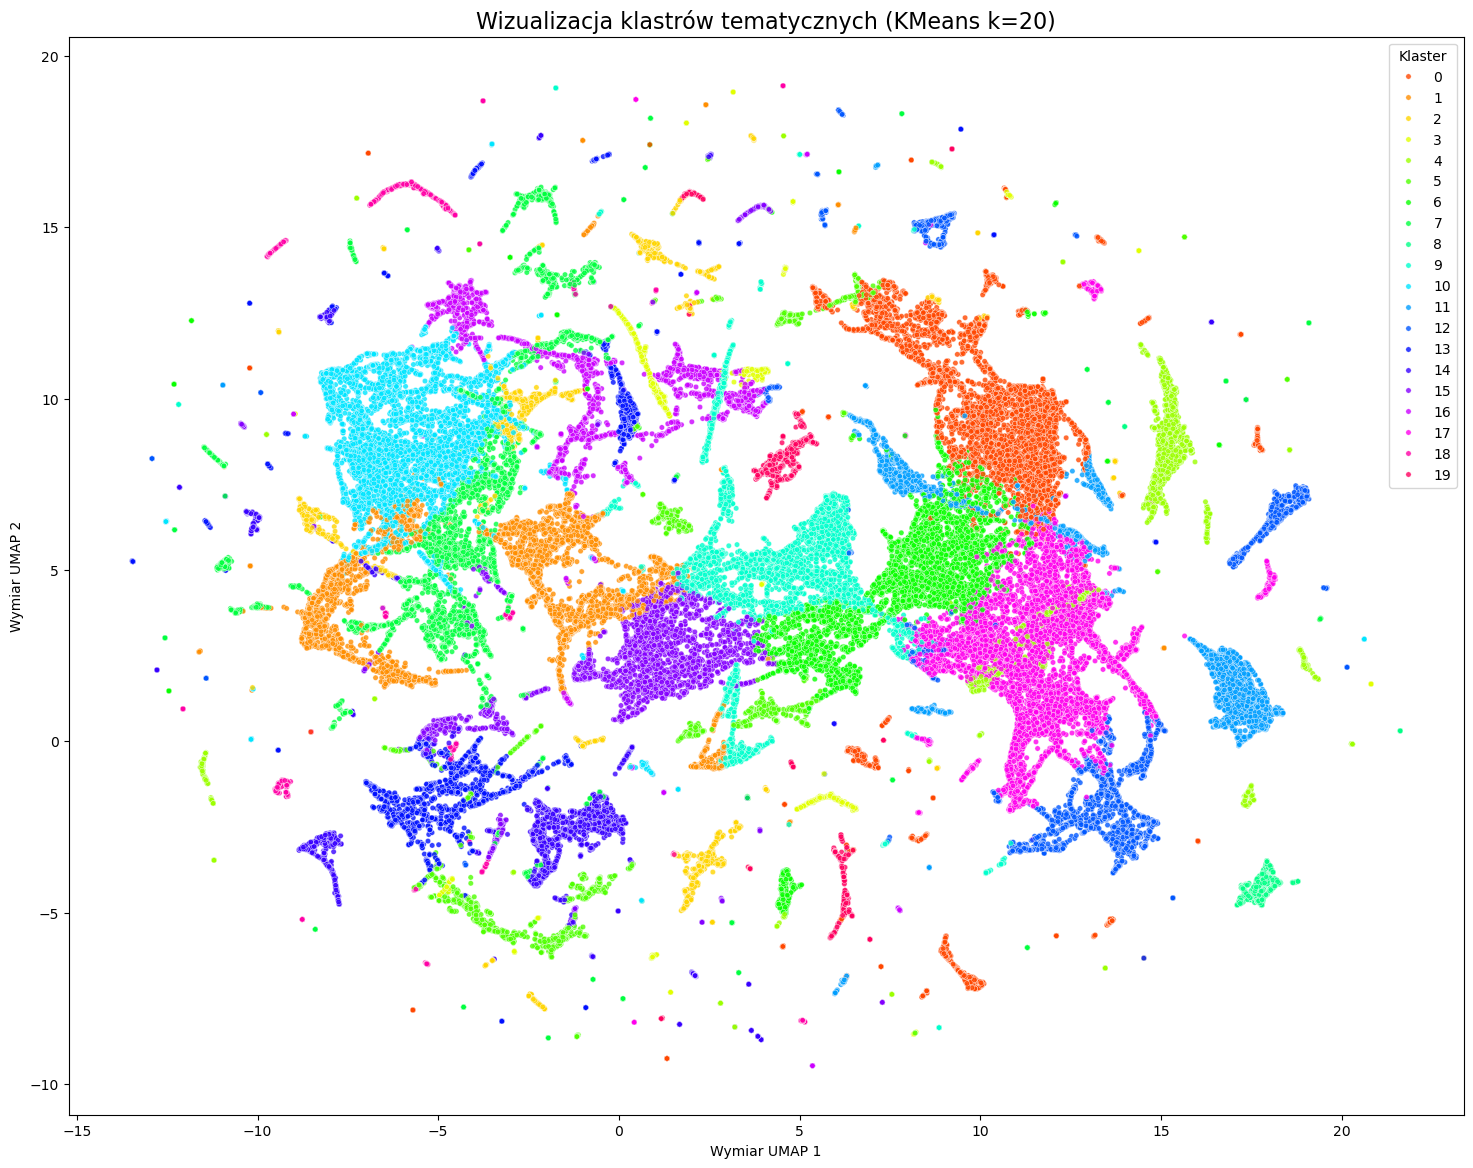

In [3]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

### wizualizacja 2D dla KMeans (100k próbek)

n_samples_viz = 100000
print(f"Tworzenie losowej próbki {n_samples_viz} dokumentów do wizualizacji...")
random_indices = np.random.choice(umap_embeddings.shape[0], size=n_samples_viz, replace=False)


umap_embeddings_sample = umap_embeddings[random_indices]

cluster_labels_sample = df_with_all_clusters['kmeans_cluster'].iloc[random_indices]

## redukcja wymiarowości z 10D do 2D (te same ustawienia UMAP co poprzednio)
reducer_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
embeddings_2d = reducer_2d.fit_transform(umap_embeddings_sample)
print("Redukcja do 2D zakończona.")

## przygotowanie DataFrame
df_viz_kmeans = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'cluster': cluster_labels_sample
})


## wykres
plt.figure(figsize=(18, 14))

sns.scatterplot(
    x='x', y='y',
    hue='cluster',
    palette=sns.color_palette("hsv", n_colors=20),
    data=df_viz_kmeans,
    s=15,
    alpha=0.8,
    legend='full'
)

plt.title('Wizualizacja klastrów tematycznych (KMeans k=20)', fontsize=16)
plt.xlabel('Wymiar UMAP 1')
plt.ylabel('Wymiar UMAP 2')
plt.legend(title='Klaster')
plt.show()

Tworzenie losowej próbki 400000 dokumentów do wizualizacji...


O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Redukcja do 2D zakończona.


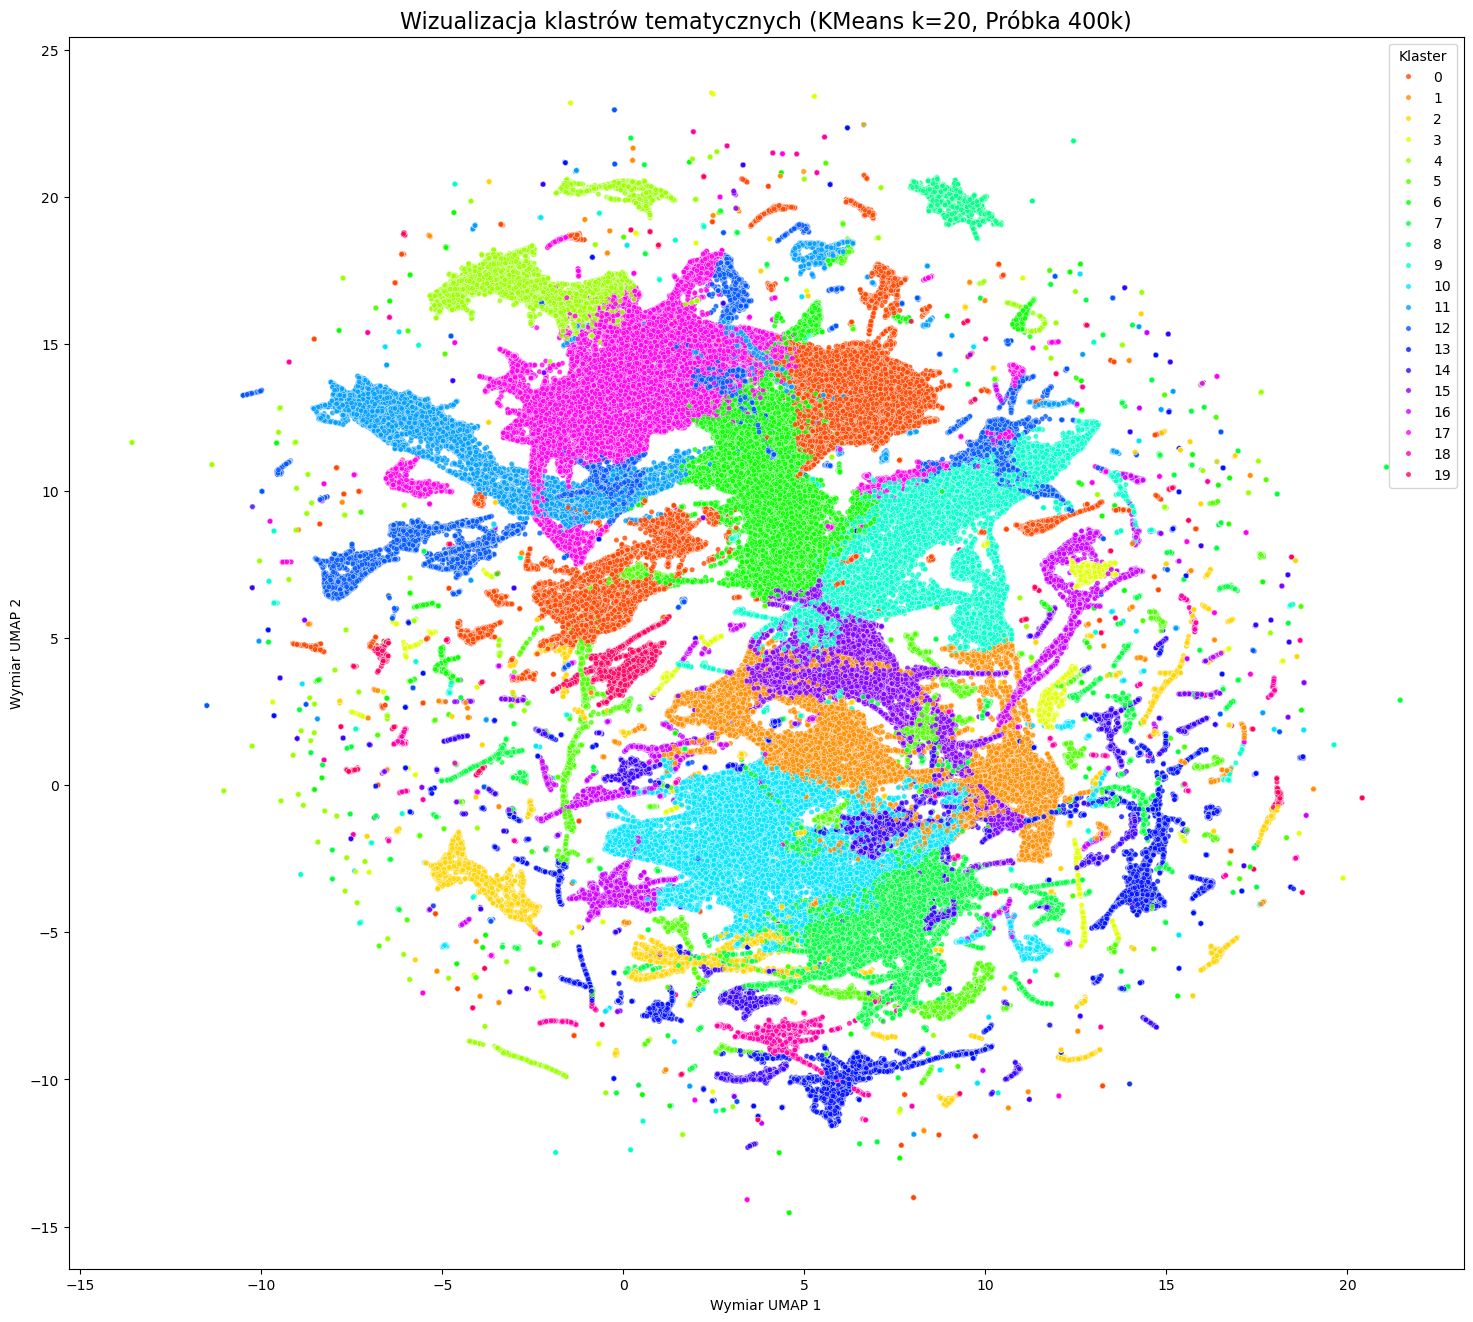

In [5]:
### wizualizacja 2D dla KMeans na połowie próbek (400k)

n_samples_viz = 400000
print(f"Tworzenie losowej próbki {n_samples_viz} dokumentów do wizualizacji...")
random_indices = np.random.choice(umap_embeddings.shape[0], size=n_samples_viz, replace=False)


umap_embeddings_sample = umap_embeddings[random_indices]

cluster_labels_sample = df_with_all_clusters['kmeans_cluster'].iloc[random_indices]

## redukcja wymiarowości z 10D do 2D (te same ustawienia UMAP co poprzednio)
reducer_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
embeddings_2d = reducer_2d.fit_transform(umap_embeddings_sample)
print("Redukcja do 2D zakończona.")

## przygotowanie DataFrame
df_viz_kmeans = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'cluster': cluster_labels_sample
})


## wykres
plt.figure(figsize=(18, 16))

sns.scatterplot(
    x='x', y='y',
    hue='cluster',
    palette=sns.color_palette("hsv", n_colors=20),
    data=df_viz_kmeans,
    s=15,
    alpha=0.8,
    legend='full'
)

plt.title('Wizualizacja klastrów tematycznych (KMeans k=20, Próbka 400k)', fontsize=16)
plt.xlabel('Wymiar UMAP 1')
plt.ylabel('Wymiar UMAP 2')
plt.legend(title='Klaster')
plt.show()

In [1]:
import pandas as pd
from tqdm import tqdm
import time
import re
import joblib
import numpy as np

### wczytywanie obiektu
df_with_all_clusters = joblib.load('df_with_all_clusters.joblib')

print("Obiekt wczytany.")

Obiekt wczytany.


In [3]:
from sklearn.feature_extraction.text import CountVectorizer

### tworzenie macierzy zliczeń słów (Document-Term Matrix)

start_time = time.time()

### konfiguracja CountVectorizer
#### max_df=0.95 - ignoruje słowa, które występują w ponad 95% dokumentów (zbyt ogólne)
#### min_df=20 - ignoruje słowa, które wystąpiły w mniej niż 20 dokumentach (zbyt rzadkie, potencjalne literówki)
#### stop_words='english' - dodatkowa warstwa dla usunięcia popularnych słów (stop words)
vectorizer_lda = CountVectorizer(
    max_df=0.95, 
    min_df=20, 
    stop_words='english'
)

### macierz na podstawie zlemmatyzowanego tekstu
dtm = vectorizer_lda.fit_transform(df_with_all_clusters['text_lemmatized'])

end_time = time.time()
print(f"Tworzenie macierzy zakończone w {(end_time - start_time):.2f} sekund.")

### wyniki
print("\nKształt macierzy Document-Term (dokumenty, unikalne słowa):")
print(dtm.shape)

Tworzenie macierzy zakończone w 29.38 sekund.

Kształt macierzy Document-Term (dokumenty, unikalne słowa):
(850367, 59300)


In [7]:
from sklearn.decomposition import LatentDirichletAllocation

### trenowanie modelu LDA (wersja zoptymalizowana)

### konfiguracja  LDA
#### n_components=20 -> szukamy 20 różnych tematów (porównanie z modelem KMeans)
#### n_jobs=-1 -> wykorzystuje wszystkie dostępne rdzenie CPU
#### random_state=42 -> zapewnia powtarzalność wyników
#### learning_method='online'  -> szybsza metoda dla dużych zbiorów
#### Optymalizacja max_iter oraz batch_size
#### max_iter=5  -> mniej iteracji dla szybszego wyniku
#### batch_size=1024  -> większy batch dla szybszego przetwarzania

lda = LatentDirichletAllocation(
    n_components=20, 
    random_state=42,
    n_jobs=-1,
    learning_method='online',
    max_iter=5,
    batch_size=1024
)

start_time = time.time()

### uruchomienie trenowania na macierzy zliczeń (dtm)
### uruchomienie trenowania ze wskazaniem na dysk C:/joblib_temp (najwięcej miejsca)
with joblib.parallel_backend('loky', temp_folder='C:/joblib_temp'):
    lda.fit(dtm)


end_time = time.time()

total_time_minutes = (end_time - start_time) / 60
print(f"\nTrenowanie LDA zakończone w {total_time_minutes:.2f} minut.")


### funkcja do wyświetlania tematów
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        #### 10 najważniejszych słów dla każdego tematu
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(f"Temat {topic_idx}: {' '.join(top_words)}")


print("\nOdkryte tematy (Top 10 słów)")
feature_names_lda = vectorizer_lda.get_feature_names_out()
display_topics(lda, feature_names_lda, 10)


Trenowanie LDA zakończone w 17.24 minut.

Odkryte tematy (Top 10 słów)
Temat 0: test sample detection testing positive method assay result detect diagnostic
Temat 1: drug treatment potential use application review effect therapeutic property agent
Temat 2: la en covid et el des les que le se
Temat 3: covid patient care study clinical hospital treatment review trial include
Temat 4: model datum method learning propose base analysis network result study
Temat 5: covid pandemic health research public social impact policy challenge global
Temat 6: study analysis result high region change datum effect increase population
Temat 7: vaccine antibody vaccination dose woman response igg mask pregnant pregnancy
Temat 8: covid health study pandemic student participant survey result mental social
Temat 9: cell immune response cd stem saudi com calf immunity tcell
Temat 10: group control diabetes increase effect level study food concentration weight
Temat 11: sarscov cell lung expression cytokine i

In [9]:
### zapis wyników z LDA

joblib.dump(lda, 'lda_model_20t.joblib')
print("Model LDA zapisany w lda_model_20t.joblib")


joblib.dump(dtm, 'dtm_matrix.joblib')
print("Macierz DTM zapisana w dtm_matrix.joblib")


joblib.dump(vectorizer_lda, 'count_vectorizer_lda.joblib')
print("Wektoryzator zapisany w count_vectorizer_lda.joblib")

Model LDA zapisany w lda_model_20t.joblib
Macierz DTM zapisana w dtm_matrix.joblib
Wektoryzator zapisany w count_vectorizer_lda.joblib


In [1]:
import pandas as pd
from tqdm import tqdm
import time
import re
import joblib
import numpy as np
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

### wczytywanie obiektów
df_with_all_clusters = joblib.load('df_with_all_clusters.joblib')


lda = joblib.load('lda_model_20t.joblib')


dtm = joblib.load('dtm_matrix.joblib')


vectorizer_lda = joblib.load('count_vectorizer_lda.joblib')


print("Obiekty wczytane.")

Obiekty wczytane.


In [3]:
### wizualizacja dla LDA

import pyLDAvis
import warnings


warnings.filterwarnings("ignore", category=FutureWarning)


### pyLDAvis do pracy w notatniku
pyLDAvis.enable_notebook()


### dane do wizualizacji (składniki dla pyLDAvis.prepare)
doc_topic_dist = lda.transform(dtm)
topic_term_dist = lda.components_
doc_lengths = dtm.sum(axis=1).A1  ##### .A1 spłaszcza macierz do wektora
vocab = vectorizer_lda.get_feature_names_out()
term_frequency = dtm.sum(axis=0).A1

### tworzenie wizualizacji
vis_data = pyLDAvis.prepare(
    topic_term_dists=topic_term_dist,
    doc_topic_dists=doc_topic_dist,
    doc_lengths=doc_lengths,
    vocab=vocab,
    term_frequency=term_frequency
)


print("Wizualizacja - wyświetlanie...")


### wyświetlenie dashboardu
vis_data

Wizualizacja - wyświetlanie...


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5     -0.472999  0.206057       1        1  14.125601
8     -0.516942 -0.021063       2        1  13.324960
3     -0.411035 -0.133568       3        1  10.421049
4     -0.250417  0.139097       4        1   8.007360
14    -0.202899 -0.232389       5        1   6.307218
12    -0.162096 -0.036936       6        1   5.132860
16    -0.073805 -0.025516       7        1   4.493449
18     0.014177 -0.090487       8        1   4.181187
6     -0.063458 -0.071691       9        1   4.176516
1     -0.014040  0.168481      10        1   3.916929
13     0.037986  0.204500      11        1   3.876274
19     0.076523  0.167976      12        1   3.282919
0      0.020019 -0.047836      13        1   3.186655
17     0.066748  0.072955      14        1   3.133129
11     0.156562  0.026472      15        1   2.872169
10     0.109334 -0.203460      16        1   2.795014
7      0.181826 -0.108757      17        1   2.219920
2      0.399287 -0.221262      18        1   2.133185
15     0.524602  0.145720      19        1   1.243483
9      0.580628  0.061706      20        1   1.170121, topic_info=           Term          Freq         Total Category  logprob  loglift
10842     covid  1.529841e+13  1.529841e+13  Default  30.0000  30.0000
38666   patient  7.325162e+12  7.325162e+12  Default  29.0000  29.0000
22107    health  5.207976e+12  5.207976e+12  Default  28.0000  28.0000
38135  pandemic  5.687174e+12  5.687174e+12  Default  27.0000  27.0000
47027   sarscov  1.074566e+12  1.074566e+12  Default  26.0000  26.0000
...         ...           ...           ...      ...      ...      ...
16773   epitope  4.233533e+09  2.525385e+10  Topic20   8.3371  18.3931
25724    innate  4.381503e+09  3.541985e+10  Topic20   8.3715  18.0891
52931   therapy  5.481531e+09  6.082766e+11  Topic20   8.5955  15.4698
52849        th  4.825839e+09  1.824715e+11  Topic20   8.4681  16.5464
54565     tumor  4.333426e+09  7.639965e+10  Topic20   8.3604  17.3094

[1501 rows x 6 columns], token_table=       Topic      Freq    Term
term                          
48         1  0.000116  abbott
48         2  0.000109  abbott
48         3  0.000085  abbott
48         4  0.000066  abbott
48         5  0.000052  abbott
...      ...       ...     ...
58626     16  0.000012     été
58626     17  0.000009     été
58626     18  0.999597     été
58626     19  0.000005     été
58626     20  0.000005     été

[25420 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 9, 4, 5, 15, 13, 17, 19, 7, 2, 14, 20, 1, 18, 12, 11, 8, 3, 16, 10])

In [5]:
### dodanie wyników LDA do głównego DataFrame

#### przypisywanie dominującego tematu LDA do każdego dokumentu
#### obliczanie prawdopodobieństwa przynależności (przez LDA) do każdego tematu dla wszystkich dokumentów
doc_topic_dist = lda.transform(dtm)

#### dla każdego dokumentu potrzebny jest indeks tematu z najwyższym prawdopodobieństwem
dominant_topic = np.argmax(doc_topic_dist, axis=1)

#### nowa kolumna do głównego DataFrame
df_with_all_clusters['lda_topic'] = dominant_topic

print("Nowa kolumna 'lda_topic' została dodana.")

print(df_with_all_clusters[['hdbscan_cluster', 'kmeans_cluster', 'lda_topic']].head())

Nowa kolumna 'lda_topic' została dodana.
   hdbscan_cluster  kmeans_cluster  lda_topic
0              456              15         16
1               -1               7         11
2               -1               7         11
3               -1               7         17
4               -1              10         13


In [7]:
### zapis zaktualizowanego DataFrame

joblib.dump(df_with_all_clusters, 'df_with_all_clusters.joblib')
print("DataFrame 'df_with_all_clusters.joblib' został zaktualizowany.")

DataFrame 'df_with_all_clusters.joblib' został zaktualizowany.


In [1]:
import pandas as pd
from tqdm import tqdm
import time
import re
import joblib
import numpy as np
import umap.umap_ as umap

### wczytywanie obiektów
df_with_all_clusters = joblib.load('df_with_all_clusters.joblib')

umap_embeddings = np.load('umap_embeddings_10d.npy')

print("Obiekty wczytane.")

Obiekty wczytane.


In [3]:
##### trenowanie / klastrowanie za pomocą modelu GMM

from sklearn.mixture import GaussianMixture

### konfiguracja  GMM
gmm = GaussianMixture(
    n_components=20,  ## te same założenia co dla KMeans, LDA
    random_state=42,
    verbose=1,         ## widoczny postęp trenowania
    verbose_interval=1 ## info o postępie co 1 iterację
)


start_time = time.time()

### uruchomienie klastrowania i przypisania do klastrów ### GMM ma metodę .fit_predict() która robi obie rzeczy naraz ###
gmm_labels = gmm.fit_predict(umap_embeddings)

end_time = time.time()
total_time_minutes = (end_time - start_time) / 60
print(f"\nKlastrowanie GMM zakończone w {total_time_minutes:.2f} minut.")

### wyniki
df_with_all_clusters['gmm_cluster'] = gmm_labels


print("\nLiczebność klastrów znalezionych przez GMM:")
print(df_with_all_clusters['gmm_cluster'].value_counts().sort_index())

Initialization 0
  Iteration 1
  Iteration 2
  Iteration 3
  Iteration 4
  Iteration 5
  Iteration 6
  Iteration 7
  Iteration 8
  Iteration 9
  Iteration 10
  Iteration 11
  Iteration 12
  Iteration 13
  Iteration 14
  Iteration 15
  Iteration 16
  Iteration 17
  Iteration 18
  Iteration 19
  Iteration 20
  Iteration 21
  Iteration 22
  Iteration 23
  Iteration 24
  Iteration 25
  Iteration 26
  Iteration 27
  Iteration 28
  Iteration 29
  Iteration 30
  Iteration 31
  Iteration 32
Initialization converged.

Klastrowanie GMM zakończone w 1.43 minut.

Liczebność klastrów znalezionych przez GMM:
gmm_cluster
0     57029
1     60421
2     53655
3     11378
4     23784
5     40370
6     63411
7     59960
8      6321
9     44359
10    65895
11    61561
12    52531
13    33518
14    26971
15    51702
16    36999
17    71110
18    13821
19    15571
Name: count, dtype: int64


In [5]:
### analiza tematyczna klastrów GMM

from sklearn.feature_extraction.text import TfidfVectorizer

### 10 największych klastrów
top_gmm_ids = df_with_all_clusters['gmm_cluster'].value_counts().head(10).index.tolist()


print("ANALIZA SŁÓW KLUCZOWYCH DLA NAJWIĘKSZYCH KLASTRÓW Z GMM")
print("="*30)

for cluster_id in top_gmm_ids:
    cluster_texts = df_with_all_clusters[df_with_all_clusters['gmm_cluster'] == cluster_id]['text_lemmatized']
    
    #### TF-IDF żeby znaleźć kluczowe słowa
    vectorizer = TfidfVectorizer(max_features=10)
    vectorizer.fit(cluster_texts)
    
    top_words = vectorizer.get_feature_names_out()
    
    print(f"\nKlaster {cluster_id} (Liczba dokumentów: {len(cluster_texts)})")
    print(f"Słowa kluczowe: {', '.join(top_words)}")

ANALIZA SŁÓW KLUCZOWYCH DLA NAJWIĘKSZYCH KLASTRÓW Z GMM

Klaster 17 (Liczba dokumentów: 71110)
Słowa kluczowe: covid, crisis, economic, health, impact, pandemic, policy, research, social, study

Klaster 10 (Liczba dokumentów: 65895)
Słowa kluczowe: cell, covid, disease, drug, infection, patient, protein, sarscov, study, virus

Klaster 6 (Liczba dokumentów: 63411)
Słowa kluczowe: care, covid, de, health, la, pandemic, patient, research, result, study

Klaster 11 (Liczba dokumentów: 61561)
Słowa kluczowe: covid, education, health, learning, online, pandemic, result, student, study, work

Klaster 1 (Liczba dokumentów: 60421)
Słowa kluczowe: antibody, cell, covid, infection, protein, sarscov, study, vaccine, viral, virus

Klaster 7 (Liczba dokumentów: 59960)
Słowa kluczowe: cell, clinical, covid, disease, infection, patient, result, risk, study, treatment

Klaster 0 (Liczba dokumentów: 57029)
Słowa kluczowe: child, covid, health, increase, mental, pandemic, patient, result, study, use

Kla

In [7]:
### zapis wyników z GMM

joblib.dump(df_with_all_clusters, 'df_with_all_clusters.joblib')
print("DataFrame 'df_with_all_clusters.joblib' został zaktualizowany o wyniki GMM.")


joblib.dump(gmm, 'gmm_model_20c.joblib')
print("Model GMM zapisany w 'gmm_model_20c.joblib'")

DataFrame 'df_with_all_clusters.joblib' został zaktualizowany o wyniki GMM.
Model GMM zapisany w 'gmm_model_20c.joblib'


In [1]:
import pandas as pd
from tqdm import tqdm
import time
import re
import joblib
import numpy as np
import umap.umap_ as umap

### wczytywanie obiektów
df_with_all_clusters = joblib.load('df_with_all_clusters.joblib')

umap_embeddings = np.load('umap_embeddings_10d.npy')

print("Obiekty wczytane.")

Obiekty wczytane.


O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Redukcja do 2D zakończona.


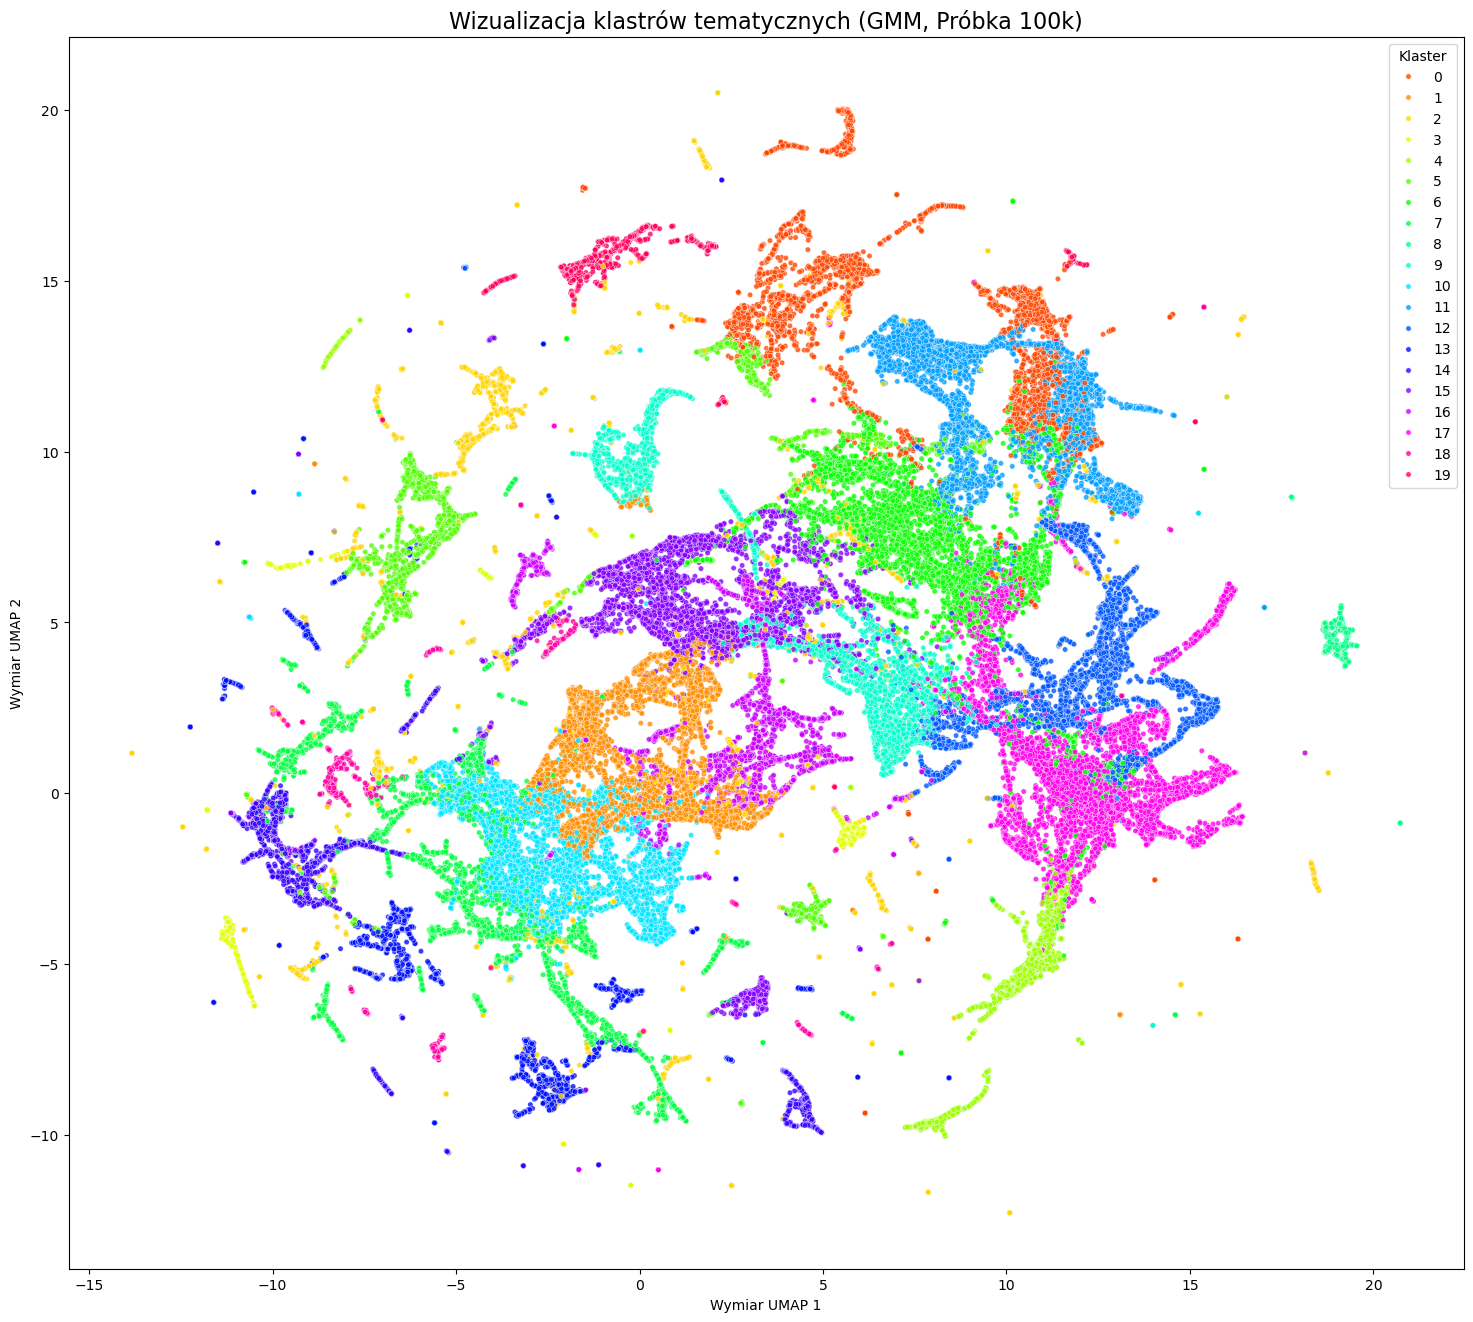

In [3]:
## wizualizacja GMM - próbka 100k

import matplotlib.pyplot as plt
import seaborn as sns


n_samples_viz = 100000
random_indices = np.random.choice(umap_embeddings.shape[0], size=n_samples_viz, replace=False)

umap_embeddings_sample = umap_embeddings[random_indices]
### pobranie etykiet z kolumny GMM
cluster_labels_sample = df_with_all_clusters['gmm_cluster'].iloc[random_indices]

### redukcja wymiarów z 10D do 2D
reducer_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
embeddings_2d = reducer_2d.fit_transform(umap_embeddings_sample)
print("Redukcja do 2D zakończona.")

### przygotowanie dataframe
df_viz_gmm = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'cluster': cluster_labels_sample
})

### wykres
plt.figure(figsize=(18, 16))

sns.scatterplot(
    x='x', y='y',
    hue='cluster',
    palette=sns.color_palette("hsv", n_colors=20),
    data=df_viz_gmm,
    s=15,
    alpha=0.8,
    legend='full'
)

plt.title('Wizualizacja klastrów tematycznych (GMM, Próbka 100k)', fontsize=16)
plt.xlabel('Wymiar UMAP 1')
plt.ylabel('Wymiar UMAP 2')
plt.legend(title='Klaster')
plt.show()

O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Redukcja do 2D zakończona.


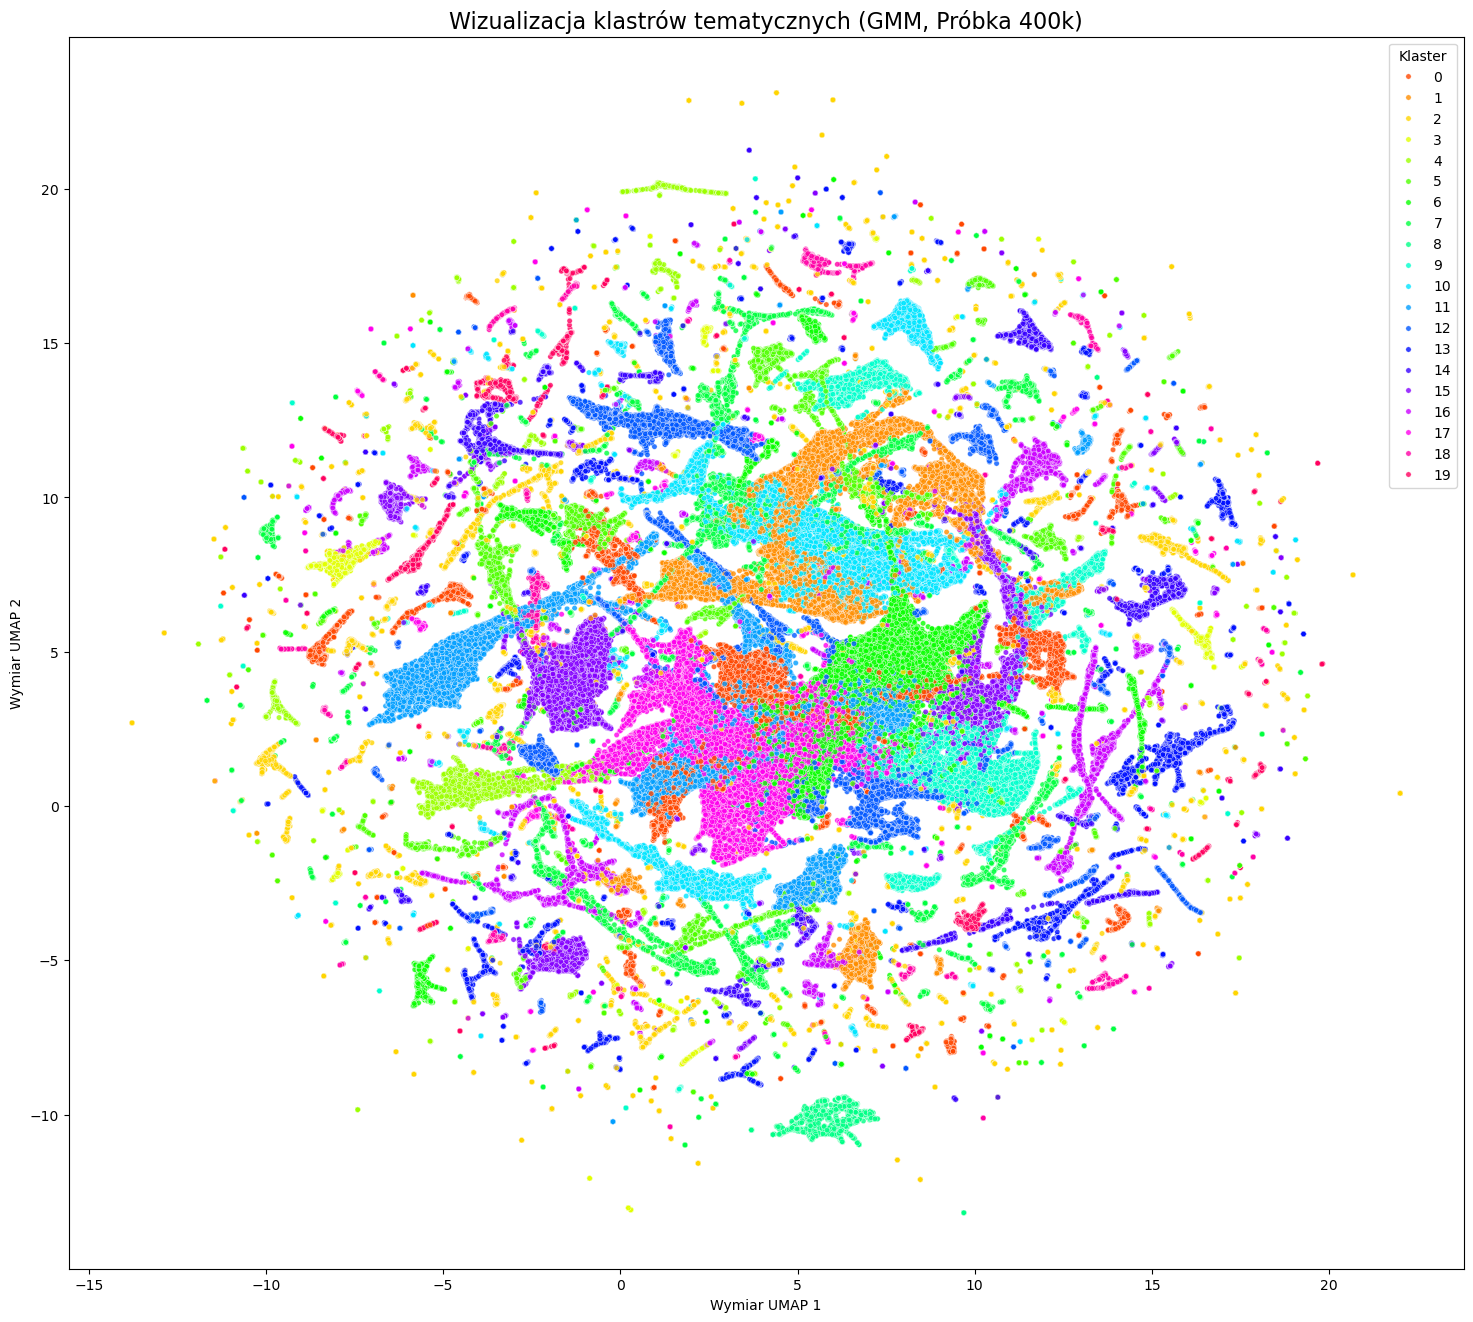

In [5]:
## wizualizacja GMM na połowie próbek (400k)

n_samples_viz = 400000
random_indices = np.random.choice(umap_embeddings.shape[0], size=n_samples_viz, replace=False)

umap_embeddings_sample = umap_embeddings[random_indices]
### pobranie etykiet z kolumny GMM
cluster_labels_sample = df_with_all_clusters['gmm_cluster'].iloc[random_indices]

### redukcja wymiarów z 10D do 2D
reducer_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
embeddings_2d = reducer_2d.fit_transform(umap_embeddings_sample)
print("Redukcja do 2D zakończona.")

### przygotowanie dataframe
df_viz_gmm = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'cluster': cluster_labels_sample
})

### wykres
plt.figure(figsize=(18, 16))

sns.scatterplot(
    x='x', y='y',
    hue='cluster',
    palette=sns.color_palette("hsv", n_colors=20),
    data=df_viz_gmm,
    s=15,
    alpha=0.8,
    legend='full'
)

plt.title('Wizualizacja klastrów tematycznych (GMM, Próbka 400k)', fontsize=16)
plt.xlabel('Wymiar UMAP 1')
plt.ylabel('Wymiar UMAP 2')
plt.legend(title='Klaster')
plt.show()